In [9]:
#=====IMPORTS======
import sys
from pathlib import Path

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

sys.path.append(str(Path("../src").resolve()))

from common_utils import (
    evaluate_predictions,
    load_split_data,
    print_evaluation_results,
    save_metrics,
    save_sklearn_model,
)

In [10]:
#=====PATHS======
TRAIN_CSV_PATH = "processed_data/dataset_20k/train.csv"
VALIDATION_CSV_PATH = "processed_data/dataset_20k/validation.csv"
TEST_CSV_PATH = "processed_data/dataset_20k/test.csv"

OUTPUT_DIRECTORY = "outputs/20k_tfidf_logreg"
MODEL_FILE_NAME = "20k_tfidf_logreg_baseline.joblib"

In [11]:
train_dataframe, validation_dataframe, test_dataframe = load_split_data(
    train_csv_path=TRAIN_CSV_PATH,
    validation_csv_path=VALIDATION_CSV_PATH,
    test_csv_path=TEST_CSV_PATH,
)

print("Train shape:", train_dataframe.shape)
print("Validation shape:", validation_dataframe.shape)
print("Test shape:", test_dataframe.shape)

print("\nTraining label distribution:")
print(train_dataframe["generated"].value_counts())

Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)

Training label distribution:
generated
1    8000
0    8000
Name: count, dtype: int64


In [12]:
tfidf_logreg_pipeline = Pipeline(
    steps=[
        (
            "tfidf_vectorizer",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),  
                min_df=5,
                max_df=0.9,
            )
        ),
        (
            "logistic_regression_classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

tfidf_logreg_pipeline

Pipeline(steps=[('tfidf_vectorizer',
                 TfidfVectorizer(max_df=0.9, max_features=20000, min_df=5,
                                 ngram_range=(1, 2))),
                ('logistic_regression_classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [13]:
tfidf_logreg_pipeline.fit(
    train_dataframe["text"],
    train_dataframe["generated"],
)

Pipeline(steps=[('tfidf_vectorizer',
                 TfidfVectorizer(max_df=0.9, max_features=20000, min_df=5,
                                 ngram_range=(1, 2))),
                ('logistic_regression_classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [14]:
validation_predicted_labels = tfidf_logreg_pipeline.predict(validation_dataframe["text"])
validation_predicted_probabilities = tfidf_logreg_pipeline.predict_proba(validation_dataframe["text"])[:, 1]

validation_results = evaluate_predictions(
    true_labels=validation_dataframe["generated"],
    predicted_labels=validation_predicted_labels,
    predicted_probabilities=validation_predicted_probabilities,
)

print_evaluation_results("TF-IDF + Logistic Regression Validation", validation_results)


=== TF-IDF + Logistic Regression Validation Results ===
Accuracy : 0.9870
Precision: 0.9890
Recall   : 0.9850
F1-score : 0.9870

Confusion Matrix:
[[989, 11], [15, 985]]

Classification Report:
              precision    recall  f1-score   support

       Human       0.99      0.99      0.99      1000
          AI       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [15]:
test_predicted_labels = tfidf_logreg_pipeline.predict(test_dataframe["text"])
test_predicted_probabilities = tfidf_logreg_pipeline.predict_proba(test_dataframe["text"])[:, 1]

test_results = evaluate_predictions(
    true_labels=test_dataframe["generated"],
    predicted_labels=test_predicted_labels,
    predicted_probabilities=test_predicted_probabilities,
)

print_evaluation_results("TF-IDF + Logistic Regression Test", test_results)


=== TF-IDF + Logistic Regression Test Results ===
Accuracy : 0.9875
Precision: 0.9929
Recall   : 0.9820
F1-score : 0.9874

Confusion Matrix:
[[993, 7], [18, 982]]

Classification Report:
              precision    recall  f1-score   support

       Human       0.98      0.99      0.99      1000
          AI       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [16]:
save_sklearn_model(
    model_object=tfidf_logreg_pipeline,
    output_directory=OUTPUT_DIRECTORY,
    file_name=MODEL_FILE_NAME,
)

save_metrics(
    evaluation_results=validation_results,
    output_directory=OUTPUT_DIRECTORY,
    file_name="validation_metrics.json",
)

save_metrics(
    evaluation_results=test_results,
    output_directory=OUTPUT_DIRECTORY,
    file_name="test_metrics.json",
)

Saved model to: outputs/20k_tfidf_logreg/20k_tfidf_logreg_baseline.joblib
Saved metrics to: outputs/20k_tfidf_logreg/validation_metrics.json
Saved metrics to: outputs/20k_tfidf_logreg/test_metrics.json


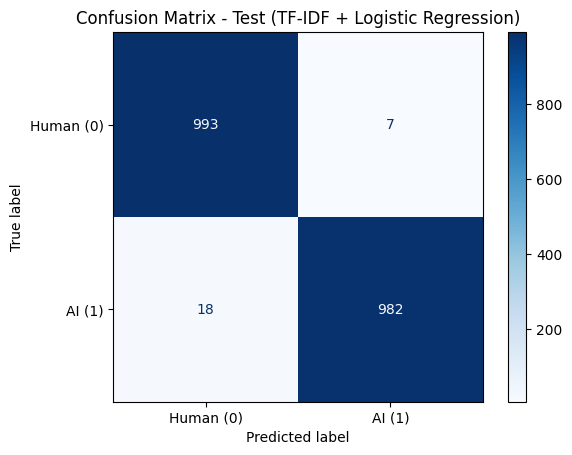

In [18]:
# %%
# ===== CONFUSION MATRIX HEATMAP =====
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Test Confusion Matrix ---
test_confusion_matrix = confusion_matrix(
    test_dataframe["generated"],
    test_predicted_labels
)

test_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=["Human (0)", "AI (1)"]
)

test_display.plot(cmap=plt.cm.Blues, colorbar=True)
plt.title("Confusion Matrix - Test (TF-IDF + Logistic Regression)")
plt.show()
